# System Tests

In [1]:
import random
import jax
import jax.numpy as jnp

In [2]:
from utils import batch_mul
import samplers
from sde import VPSDE, subVPSDE, VESDE
import likelihood

### General Variables

In [3]:
batch_size = 4
normal = jax.random.normal
jax.random.normal = lambda key, shape: jnp.full(shape, 0.5)

## Utility Functions

### Batch Multiplications

In [4]:
a = jnp.array([1.0,2.0, 0.5, 10.0]) # (4,)
b = jnp.ones((batch_size, 32,32,3)) # (4,32,32,3)
result = batch_mul(a,b)

assert result.shape == b.shape, f'Expected {b.shape} array, got {result.shape}'

expected = a.reshape(batch_size, 1,1,1)

assert jnp.allclose(result, expected), "Result does not match expected product"

## SDEs

In [5]:
shape = (batch_size,4,4,3)
x = jnp.ones(shape)
t = jnp.full((batch_size,),0.5)
score = jnp.full(shape, 0.7)

### VP SDE

In [6]:
vp_sde = VPSDE(0.1, 20, 10)
rng = jax.random.PRNGKey(0)
mean, std = vp_sde.marginal_prob(x,t)
f, g = vp_sde.sde(x,t)
prior_sample = vp_sde.prior_sampling(rng, shape)
rev_f, rev_g = vp_sde.reverse_sde(x,t,score,False)
rev_f_flow, _ = vp_sde.reverse_sde(x,t,score,True)

expected_f = jnp.full(shape, -5.025)
expected_g = jnp.full((batch_size,), 3.17017)
expected_mean = jnp.full(shape, 0.281184)
expected_std = jnp.full(shape, 0.959654)
expected_sample = jnp.full(shape, 0.5)
expected_rev_f = jnp.full(shape, -12.06)
expected_rev_g = jnp.full((batch_size,),3.17017)
expected_rev_f_flow = jnp.full(shape, -8.5425)


assert jnp.allclose(f, expected_f), 'Mismatch in f'
assert jnp.allclose(g, expected_g), 'Mismatch in g'
assert jnp.allclose(mean, expected_mean), 'Mismatch in mean'
assert jnp.allclose(std, expected_std), 'Mismatch in std'
assert jnp.allclose(prior_sample, expected_sample), 'Mismatch in prior sample'
assert jnp.allclose(rev_f, expected_rev_f), 'Mismatch in rev_f'
assert jnp.allclose(rev_g, expected_rev_g), 'Mismatch in rev_g'
assert jnp.allclose(rev_f_flow, expected_rev_f_flow), 'Mismatch in rev_f when probability flow=True'

### Sub-VP SDE

In [7]:
sub_vp_sde = subVPSDE(0.1, 20, 10)
rng = jax.random.PRNGKey(0)
mean, std = sub_vp_sde.marginal_prob(x,t)
f, g = sub_vp_sde.sde(x,t)
prior_sample = sub_vp_sde.prior_sampling(rng, shape)
rev_f, rev_g = sub_vp_sde.reverse_sde(x,t,score,False)
rev_f_flow, _ = sub_vp_sde.reverse_sde(x,t,score,True)

expected_f = jnp.full(shape, -5.025)
expected_g = jnp.full((batch_size,), 3.16024)
expected_mean = jnp.full(shape, 0.281184)
expected_std = jnp.full(shape, 0.92093)
expected_sample = jnp.full(shape, 0.5)
expected_rev_f = jnp.full(shape, -12.016024)
expected_rev_g = jnp.full((batch_size,), 3.16024)
expected_rev_f_flow = jnp.full(shape, -8.5205)


assert jnp.allclose(f, expected_f), 'Mismatch in f'
assert jnp.allclose(g, expected_g), 'Mismatch in g'
assert jnp.allclose(mean, expected_mean), 'Mismatch in mean'
assert jnp.allclose(std, expected_std), 'Mismatch in std'
assert jnp.allclose(prior_sample, expected_sample), 'Mismatch in prior sample'
assert jnp.allclose(rev_f, expected_rev_f), 'Mismatch in rev_f'
assert jnp.allclose(rev_g, expected_rev_g), 'Mismatch in rev_g'
assert jnp.allclose(rev_f_flow, expected_rev_f_flow), 'Mismatch in rev_f when probability flow=True'

### VE SDE

In [8]:
ve_sde = VESDE(0.01, 50, 10)
rng = jax.random.PRNGKey(0)
mean, std = ve_sde.marginal_prob(x,t)
f, g = ve_sde.sde(x,t)
prior_sample = ve_sde.prior_sampling(rng, shape)
rev_f, rev_g = ve_sde.reverse_sde(x,t,score,False)
rev_f_flow, _ = ve_sde.reverse_sde(x,t,score,True)

expected_f = jnp.full(shape, 0)
expected_g = jnp.full((batch_size,), 2.918423)
expected_mean = jnp.full(shape, 1.0)
expected_std = jnp.full(shape, 0.707106)
expected_sample = jnp.full(shape, 0.5)*50
expected_rev_f = jnp.full(shape, -5.962035)
expected_rev_g = jnp.full((batch_size,), 2.918423)
expected_rev_f_flow = jnp.full(shape, -2.9810176)


assert jnp.allclose(f, expected_f), 'Mismatch in f'
assert jnp.allclose(g, expected_g), 'Mismatch in g'
assert jnp.allclose(mean, expected_mean), 'Mismatch in mean'
assert jnp.allclose(std, expected_std), 'Mismatch in std'
assert jnp.allclose(prior_sample, expected_sample), 'Mismatch in prior sample'
assert jnp.allclose(rev_f, expected_rev_f), 'Mismatch in rev_f'
assert jnp.allclose(rev_g, expected_rev_g), 'Mismatch in rev_g'
assert jnp.allclose(rev_f_flow, expected_rev_f_flow), 'Mismatch in rev_f when probability flow=True'

## Samplers

### Simple Predictor and Correctors

In [9]:
shape = (batch_size,4,4,3)
x = jnp.ones(shape)
t = jnp.full((batch_size,),0.5)

In [10]:
predictor = samplers.Predictor()
corrector = samplers.Corrector()

pred_output = predictor.update_fn(rng=None, x=x, t=None)
corr_output = corrector.update_fn(rng=None, x=x, t=None)

assert jnp.allclose(pred_output[0],x), 'Predictor output does not match expected value'
assert jnp.allclose(pred_output[1],x), 'Predictor mean does not match expected value'
assert jnp.allclose(corr_output[0],x), 'Corrector output does not match expected value'
assert jnp.allclose(corr_output[1],x), 'Corrector mean does not match expected value'

### Dummy Objects and Functions

In [11]:
class dummySDE:
    def __init__(self):
        self.N = 10
        self.T = 1.
    
    def reverse_sde(self, x,t,score,probability_flow=False):
        f = jnp.full_like(x,2.)
        batch_size=x.shape[0]
        G = jnp.full((batch_size,), 3.)
        return f,G
    
    def prior_sampling(self, rng, shape):
        return jnp.ones(shape)

sde = dummySDE()

In [12]:
class dummyVPSDE(VPSDE):
    def __init__(self):
        self.N = 10
        self.T = 1.0
        self.discrete_betas = jnp.full((self.N), 0.4)
        self.alphas = jnp.full((self.N), 0.6)
    
    def reverse_sde(self, x,t,score,probability_flow=False):
        f = jnp.full_like(x,2.)
        batch_size=x.shape[0]
        G = jnp.full((batch_size,), 3.)
        return f,G

    def marginal_prob(self, x, t):
        return 0, 0.3

vp_sde = dummyVPSDE()

In [13]:
class dummyVESDE(VESDE):
    def __init__(self):
        self.N = 10
        self.T = 1
        self.discrete_sigmas = jnp.array([0.5, 0.3]*5)

    def marginal_prob(self, x, t):
        return 0, 0.3

ve_sde = dummyVESDE()

In [14]:
def dummy_score_fn(x,t):
    return jnp.full_like(x, 0.7)

### Euler-Maruyama Predictor

$x_{mean} = x-f*dt$

$x_{sample} = x_{mean}+G*\sqrt{dt}*z$

In [15]:
predictor = samplers.EulerMaruyamaPredictor(sde,dummy_score_fn, False)
rng = jax.random.PRNGKey(0)
x_sample, x_mean = predictor.update_fn(rng,x,t)

expected_mean = jnp.full(shape,0.8)
expected_sample = jnp.full(shape, (16+3*jnp.sqrt(10))/20)

assert jnp.allclose(x_sample, expected_sample, atol=1e-4), "Predictor output does not match expected value"
assert jnp.allclose(x_mean, expected_mean, atol=1e-4), "Predictor mean does not match expected value"

### Reverse Diffusion Predictor

$x_{mean} = x-f$ 

$x_{sample} = x_{mean}+G*z$

In [16]:
predictor = samplers.ReverseDiffusionPredictor(sde, dummy_score_fn, False)
rng = jax.random.PRNGKey(0)
x_sample, x_mean = predictor.update_fn(rng,x,t)

expected_mean = jnp.full(shape, -1.)
expected_sample = jnp.full(shape, 0.5)

assert jnp.allclose(x_sample, expected_sample, atol=1e-5), "Predictor output does not match expected value"
assert jnp.allclose(x_mean, expected_mean, atol=1e-5), "Predictor mean does not match expected value"

### Ancestral Sampling Predictor

#### VP SDE

$x_{mean} = \frac{x+\beta_i * s(x, i)}{\sqrt{1-\beta_i}}$

$x_{sample} = x_{mean} + \sqrt{\beta_i}*z$

In [17]:
predictor = samplers.AncestralSamplingPredictor(vp_sde, dummy_score_fn, probability_flow=False)
rng = jax.random.PRNGKey(0)
x_sample, x_mean = predictor.update_fn(rng, x, t)

expected_mean = jnp.full(shape, 32*jnp.sqrt(15)/75)
expected_sample = jnp.full(shape, (64*jnp.sqrt(15)+15*jnp.sqrt(10))/150)

assert jnp.allclose(x_sample, expected_sample, atol=1e-5), "Predictor output does not match expected value"
assert jnp.allclose(x_mean, expected_mean, atol=1e-5), "Predictor mean does not match expected value"

#### VE SDE

$x_{mean} = x+(\sigma_i^2-\sigma_{i-1}^2)*s(x,i)$

$x_{sample} = x_{mean}+\sqrt{\frac{\sigma_{i-1}^2*(\sigma_i^2-\sigma_{i-1}^2)}{\sigma_i^2}}*z$

In [18]:
predictor = samplers.AncestralSamplingPredictor(ve_sde, dummy_score_fn, probability_flow=False)
rng = jax.random.PRNGKey(0)
x_sample, x_mean = predictor.update_fn(rng,x,t)

expected_mean = jnp.full(shape, 139/125)
expected_sample = jnp.full(shape, 154/125)

assert jnp.allclose(x_sample, expected_sample, atol=1e-5), "Predictor output does not match expected value"
assert jnp.allclose(x_mean, expected_mean, atol=1e-5), "Predictor mean does not match expected value"

### LangevinCorrector

#### VP SDE

In [19]:
corrector = samplers.LangevinCorrector(vp_sde, dummy_score_fn, 0.1, 2)
rng = jax.random.PRNGKey(0)
x_sample, x_mean = corrector.update_fn(rng, x, t)

expected_mean = jnp.full(shape, 1.0638997)
expected_sample = jnp.full(shape, 1.119228)

assert jnp.allclose(x_sample, expected_sample, atol=1e-5), "Corrector output does not match expected value"
assert jnp.allclose(x_mean, expected_mean, atol=1e-5), "Corrector mean does not match expected value"

#### VE SDE

In [20]:
corrector = samplers.LangevinCorrector(ve_sde, dummy_score_fn, 0.1, 2)
rng = jax.random.PRNGKey(0)
x_sample, x_mean = corrector.update_fn(rng, x, t)

expected_mean = jnp.full(shape, 1.0857143)
expected_sample = jnp.full(shape, 1.1571429)

assert jnp.allclose(x_sample, expected_sample, atol=1e-5), "Corrector output does not match expected value"
assert jnp.allclose(x_mean, expected_mean, atol=1e-5), "Corrector mean does not match expected value"

### Annealed Langevin Corrector

#### VP SDE

In [21]:
corrector = samplers.AnnealedLangevinCorrector(vp_sde, dummy_score_fn, 0.1, 2)
rng = jax.random.PRNGKey(0)
x_sample, x_mean = corrector.update_fn(rng, x, t)

expected_mean = jnp.full(shape, 1.0247499)
expected_sample = jnp.full(shape, 1.0479878)

assert jnp.allclose(x_sample, expected_sample, atol=1e-5), "Corrector output does not match expected value"
assert jnp.allclose(x_mean, expected_mean, atol=1e-5), "Corrector mean does not match expected value"

#### VE SDE

In [22]:
corrector = samplers.AnnealedLangevinCorrector(ve_sde, dummy_score_fn, 0.1, 2)
rng = jax.random.PRNGKey(0)
x_sample, x_mean = corrector.update_fn(rng, x, t)

expected_mean = jnp.full(shape, 1.03252)
expected_sample = jnp.full(shape, 1.06252)

assert jnp.allclose(x_sample, expected_sample, atol=1e-5), "Corrector output does not match expected value"
assert jnp.allclose(x_mean, expected_mean, atol=1e-5), "Corrector mean does not match expected value"

### PC-Sampling

In [23]:
predictor, corrector = samplers.Predictor(), samplers.Corrector()
inverse_scaler = lambda x: x*2.0

sampler_fn = samplers.pc_sampler(sde, shape, predictor, corrector, inverse_scaler, 1, True)
rng = jax.random.PRNGKey(0)
x_final, evals = sampler_fn(rng)

expected_evals = sde.N*2
expected_x = jnp.full(shape, 2.0)

assert evals == expected_evals, 'Mismatch in number of evaluations'
assert jnp.allclose(x_final, expected_x), "Sampler output does not match expected value"

### ODE-Sampling

In [24]:
inverse_scaler = lambda x: x*2.0

sampler = samplers.ode_sampler(
    sde=sde,
    score_fn=dummy_score_fn,
    shape=shape,
    inverse_scaler=inverse_scaler,
    denoise=True
)

rng = jax.random.PRNGKey(0)
x_final, nfe = sampler(rng)
assert x_final.shape == shape, "Shape mismatch"
assert nfe > 0, "Zero function evaluations"

## Likelihood Computation

In [25]:
likelihood_fn = likelihood.get_likelihood_fn(vp_sde, dummy_score_fn, inverse_scaler)
rng = jax.random.PRNGKey(0)
log_likelihood, bpd, z, nfe = likelihood_fn(rng, x)

assert jnp.all(~jnp.isnan(log_likelihood)), 'NaN in Log-likelihood'
assert jnp.all(~jnp.isnan(bpd)), 'NaN in Bits/dimension'
assert jnp.all(~jnp.isnan(z)), 'NaN in z'
assert nfe > 0, 'Zero function evaluations'

## SDEs + Predictors/Correctors

In [26]:
shape = (batch_size,4,4,3)
x = jnp.ones(shape)
t = jnp.full((batch_size,),0.5)
rng = jax.random.PRNGKey(0)

In [27]:
vp_sde = VPSDE(0.1, 20, 10)
sub_vp_sde = subVPSDE(0.1, 20, 10)
ve_sde = VESDE(0.01, 50, 10)

### Euler-Maruyama

In [28]:
em_vp = samplers.EulerMaruyamaPredictor(vp_sde, dummy_score_fn, False)
x_sample, x_mean = em_vp.update_fn(rng, x, t)
assert jnp.all(~jnp.isnan(x_mean)), 'NaN in mean'
assert jnp.all(~jnp.isnan(x_sample)), 'NaN in sample'

In [29]:
em_sub_vp = samplers.EulerMaruyamaPredictor(sub_vp_sde, dummy_score_fn, False)
x_sample, x_mean = em_sub_vp.update_fn(rng, x, t)
assert jnp.all(~jnp.isnan(x_mean)), 'NaN in mean'
assert jnp.all(~jnp.isnan(x_sample)), 'NaN in sample'

In [30]:
em_ve = samplers.EulerMaruyamaPredictor(ve_sde, dummy_score_fn, False)
x_sample, x_mean = em_ve.update_fn(rng, x, t)
assert jnp.all(~jnp.isnan(x_mean)), 'NaN in mean'
assert jnp.all(~jnp.isnan(x_sample)), 'NaN in sample'

### Reverse Diffusion

In [31]:
rd_vp = samplers.ReverseDiffusionPredictor(vp_sde, dummy_score_fn, False)
x_sample, x_mean = rd_vp.update_fn(rng, x, t)
assert jnp.all(~jnp.isnan(x_mean)), 'NaN in mean'
assert jnp.all(~jnp.isnan(x_sample)), 'NaN in sample'

In [32]:
rd_sub_vp = samplers.ReverseDiffusionPredictor(sub_vp_sde, dummy_score_fn, False)
x_sample, x_mean = rd_sub_vp.update_fn(rng, x, t)
assert jnp.all(~jnp.isnan(x_mean)), 'NaN in mean'
assert jnp.all(~jnp.isnan(x_sample)), 'NaN in sample'

In [33]:
rd_ve = samplers.ReverseDiffusionPredictor(ve_sde, dummy_score_fn, False)
x_sample, x_mean = rd_ve.update_fn(rng, x, t)
assert jnp.all(~jnp.isnan(x_mean)), 'NaN in mean'
assert jnp.all(~jnp.isnan(x_sample)), 'NaN in sample'

### Ancestral Sampling

In [34]:
as_vp = samplers.AncestralSamplingPredictor(vp_sde, dummy_score_fn, False)
x_sample, x_mean = as_vp.update_fn(rng, x, t)
assert jnp.all(~jnp.isnan(x_mean)), 'NaN in mean'
assert jnp.all(~jnp.isnan(x_sample)), 'NaN in sample'

In [35]:
as_ve = samplers.AncestralSamplingPredictor(ve_sde, dummy_score_fn, False)
x_sample, x_mean = as_ve.update_fn(rng, x, t)
assert jnp.all(~jnp.isnan(x_mean)), 'NaN in mean'
assert jnp.all(~jnp.isnan(x_sample)), 'NaN in sample'

### Langevin

In [36]:
l_vp = samplers.LangevinCorrector(vp_sde, dummy_score_fn, 0.1, 10)
x_sample, x_mean = l_vp.update_fn(rng, x, t)
assert jnp.all(~jnp.isnan(x_mean)), 'NaN in mean'
assert jnp.all(~jnp.isnan(x_sample)), 'NaN in sample'

In [37]:
l_ve = samplers.LangevinCorrector(ve_sde, dummy_score_fn, 0.1, 10)
x_sample, x_mean = l_ve.update_fn(rng, x, t)
assert jnp.all(~jnp.isnan(x_mean)), 'NaN in mean'
assert jnp.all(~jnp.isnan(x_sample)), 'NaN in sample'

### Annealed Langevin

In [38]:
al_vp = samplers.AnnealedLangevinCorrector(vp_sde, dummy_score_fn, 0.1, 10)
x_sample, x_mean = al_vp.update_fn(rng, x, t)
assert jnp.all(~jnp.isnan(x_mean)), 'NaN in mean'
assert jnp.all(~jnp.isnan(x_sample)), 'NaN in sample'

In [39]:
al_ve = samplers.AnnealedLangevinCorrector(ve_sde, dummy_score_fn, 0.1, 10)
x_sample, x_mean = al_ve.update_fn(rng, x, t)
assert jnp.all(~jnp.isnan(x_mean)), 'NaN in mean'
assert jnp.all(~jnp.isnan(x_sample)), 'NaN in sample'

### PC Sampling with actual SDEs

In [40]:
jax.random.normal = normal

In [41]:
rng = jax.random.PRNGKey(0)
ve_sde = VESDE(0.01, 50, 10)
as_ve = samplers.AncestralSamplingPredictor(ve_sde, dummy_score_fn, False)
al_ve = samplers.AnnealedLangevinCorrector(ve_sde, dummy_score_fn, 0.1, 10)
inverse_scaler = lambda x: x*2.0
sampler = samplers.pc_sampler(ve_sde, shape, as_ve, al_ve, inverse_scaler, n_steps=100, denoise=True)
x_final, evals = sampler(rng)
assert jnp.all(~jnp.isnan(x_final)), 'NaN in sample'
print(x_final)

[[[[3982.3398 4102.6924 4520.3535]
   [4300.542  4081.391  4150.6924]
   [4093.997  4318.4614 4065.7874]
   [4503.267  4309.2876 4411.331 ]]

  [[4068.3154 4205.833  4337.3667]
   [4373.275  4168.2217 4192.2847]
   [4175.6753 4103.0146 4265.0693]
   [4236.5903 4581.965  4398.689 ]]

  [[4297.86   4232.005  4417.8774]
   [4630.432  4172.1084 4197.449 ]
   [4301.2246 4238.1973 4350.272 ]
   [4501.3013 4289.803  4274.8545]]

  [[3960.621  4227.7637 4333.668 ]
   [4220.944  4066.5984 4190.3315]
   [4393.2285 4340.969  4386.329 ]
   [4315.2305 4536.4946 4453.7124]]]


 [[[4329.4087 4437.804  4224.05  ]
   [4165.641  4413.97   4169.7646]
   [4272.668  4143.8086 4372.7285]
   [4355.812  4389.2563 4569.6797]]

  [[4164.383  4283.661  4294.5376]
   [4464.0103 4286.441  4481.5923]
   [4538.5234 4113.854  4398.046 ]
   [4445.575  4195.3457 4556.1753]]

  [[4372.579  4327.3354 4419.097 ]
   [4272.7925 4320.724  4243.0483]
   [4284.9    4333.9087 4152.0337]
   [4375.3228 4367.13   4364.0312]]

  [[

## Entire System Test

In [42]:
from config import get_config_local
from train import train
from model_utils import get_score_fn

In [43]:
configuration = get_config_local()

Training for 100 iterations...
Step 10/100, Loss: 33487.16
Step 20/100, Loss: 3431.81
Step 30/100, Loss: 297570.53
Step 40/100, Loss: 3693.40
Step 50/100, Loss: 48861.43
Step 60/100, Loss: 17415.15
Step 70/100, Loss: 4405.59
Step 80/100, Loss: 11345.95
Step 90/100, Loss: 17414.26
Step 100/100, Loss: 3012.97


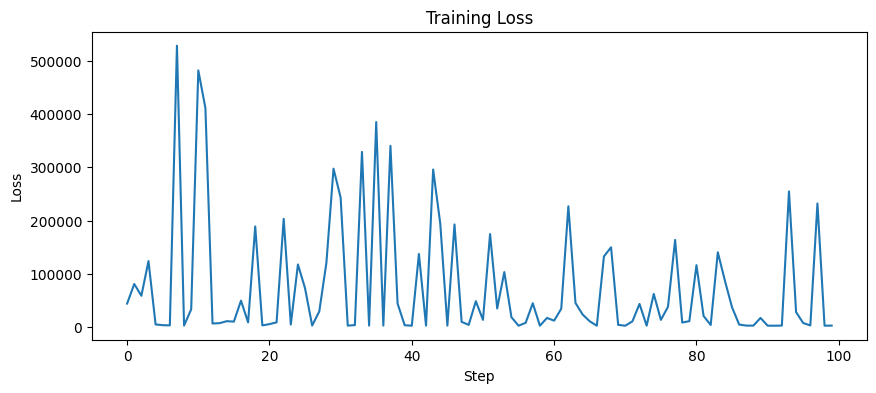

Saved loss_curve.png


In [44]:
params, model, sde = train(configuration)

In [45]:
from samplers import get_sampler
import jax.numpy as jnp
import jax

In [46]:
score_fn = get_score_fn(sde, model, params, continuous=configuration.training.continuous)
sampler = get_sampler(sde, score_fn, configuration)
rng = jax.random.PRNGKey(0)
x_final, _ = sampler(rng)
print(x_final)

[[[[ 6.93147812e+01 -6.43117218e+01  6.23312874e+01]
   [ 4.97586632e+01 -2.11802689e+02 -3.12508636e+02]
   [ 2.19611694e+02 -7.75163651e+01 -2.97059418e+02]
   ...
   [ 6.17039757e+01  2.88408081e+02  6.06146423e+02]
   [-2.79543060e+02 -1.36688751e+02  2.34484299e+02]
   [ 2.28880981e+02  7.59570312e+01 -8.58433762e+01]]

  [[ 3.89947367e+00 -1.00302544e+02  2.47612396e+02]
   [ 8.46218948e+01 -1.87586761e+02  8.29160843e+01]
   [ 2.39877640e+02 -3.97724304e+01 -2.54159805e+02]
   ...
   [-3.11665436e+02  4.39058876e+01 -1.41117945e+01]
   [-5.20778564e+02  9.23701935e+01 -6.22674904e+01]
   [-3.55277100e+02  3.48465210e+02 -2.41412018e+02]]

  [[-5.11901665e+00 -4.26667572e+02 -9.70688019e+01]
   [-4.85355988e+02 -1.96041916e+02  2.30440460e+02]
   [-3.73330811e+02  3.37133850e+02  2.22083282e+01]
   ...
   [-8.95748215e+01 -2.16753601e+02  3.83138367e+02]
   [-6.98087708e+02 -3.22469673e+01 -2.55015144e+01]
   [-1.68758148e+02  3.20352142e+02  7.35121826e+02]]

  ...

  [[ 2.04017